### Crop **predictor**

# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 2:loading data set

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/nileshely/Crop-Recommendation/main/Crop_Recommendation.csv"
df = pd.read_csv(url)

# Display the first few rows
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


# Step 3: Check & Preprocess Data

In [4]:
# Calculate the mean of only numeric columns
numeric_df = df.select_dtypes(include=np.number)
df.fillna(numeric_df.mean(), inplace=True)  # Fill missing values with column means

# Step 4: Explore the Dataset

In [5]:
# Check the structure of the dataset
df.info()

# Get summary statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,0
Nitrogen,0
Phosphorus,0
Potassium,0
Temperature,0
Humidity,0
pH_Value,0
Rainfall,0
Crop,0


### Check Column Names

In [6]:
print(df.columns)

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'],
      dtype='object')


## Adjust Column Names

In [7]:
df.columns = df.columns.str.lower()  # Convert all column names to lowercase for consistency
print(df.columns)  # Check again

Index(['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity',
       'ph_value', 'rainfall', 'crop'],
      dtype='object')


## Step 5: Visualize the Data

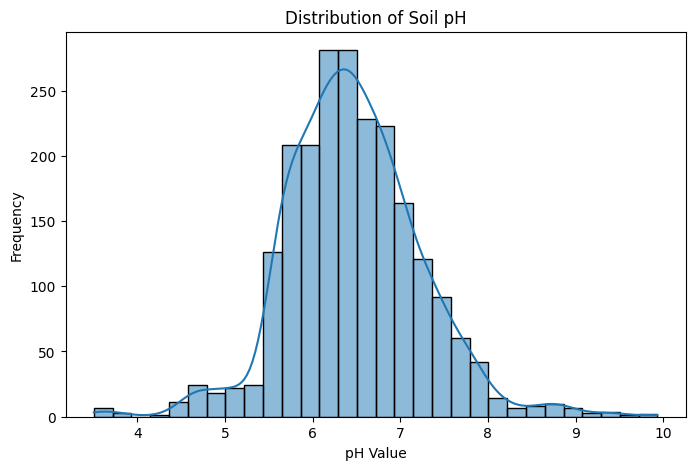

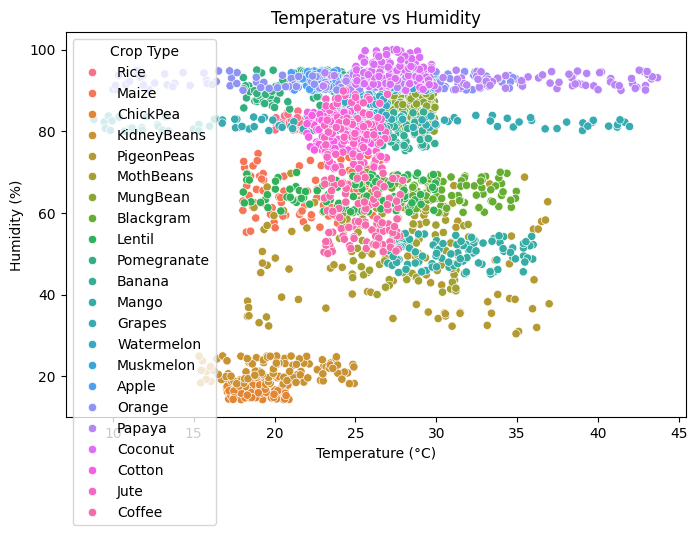

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of soil pH
plt.figure(figsize=(8, 5))
sns.histplot(df['ph_value'], bins=30, kde=True)  # Correct column name
plt.title("Distribution of Soil pH")
plt.xlabel("pH Value")
plt.ylabel("Frequency")
plt.show()

# Scatter plot of temperature vs humidity
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["temperature"], y=df["humidity"], hue=df["crop"])  # Correct column name
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.legend(title="Crop Type")
plt.show()

# Step 6 : Prepare Data for Training

In [9]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(columns=["crop"])  # Remove the crop column
y = df["crop"]

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")

Data split successfully!


# Step 7 : Train a Model

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Step 7: Make Predictions

In [11]:
# Predict on the test dataset
y_pred = model.predict(X_test)

# Show sample predictions
print("Sample Predictions:")
print(pd.DataFrame({"Actual": y_test[:10].values, "Predicted": y_pred[:10]}))

Sample Predictions:
       Actual   Predicted
0   Muskmelon   Muskmelon
1  Watermelon  Watermelon
2      Papaya      Papaya
3      Papaya      Papaya
4       Apple       Apple
5       Mango       Mango
6       Apple       Apple
7   MothBeans   MothBeans
8    MungBean    MungBean
9      Lentil      Lentil


# Step 8: Evaluate the Model

In [12]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.32%
